<a href="https://colab.research.google.com/github/marioguerrerosalah/APRENDIZAJE--SUPERVISADO/blob/main/TALLER_DE_REGRESION_LOGISTICA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**TALLER DE REGRESION LOGISTICA**

1. Cargamos las librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

2. Traemos el archivo desde drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path= '/content/drive/MyDrive/APREN. SUPERVISADO/framingham.xls'
df= pd.read_csv(path)

In [ ]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


3. Eliminamos los faltantes

In [ ]:
df.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


4. Matriz de correlacion

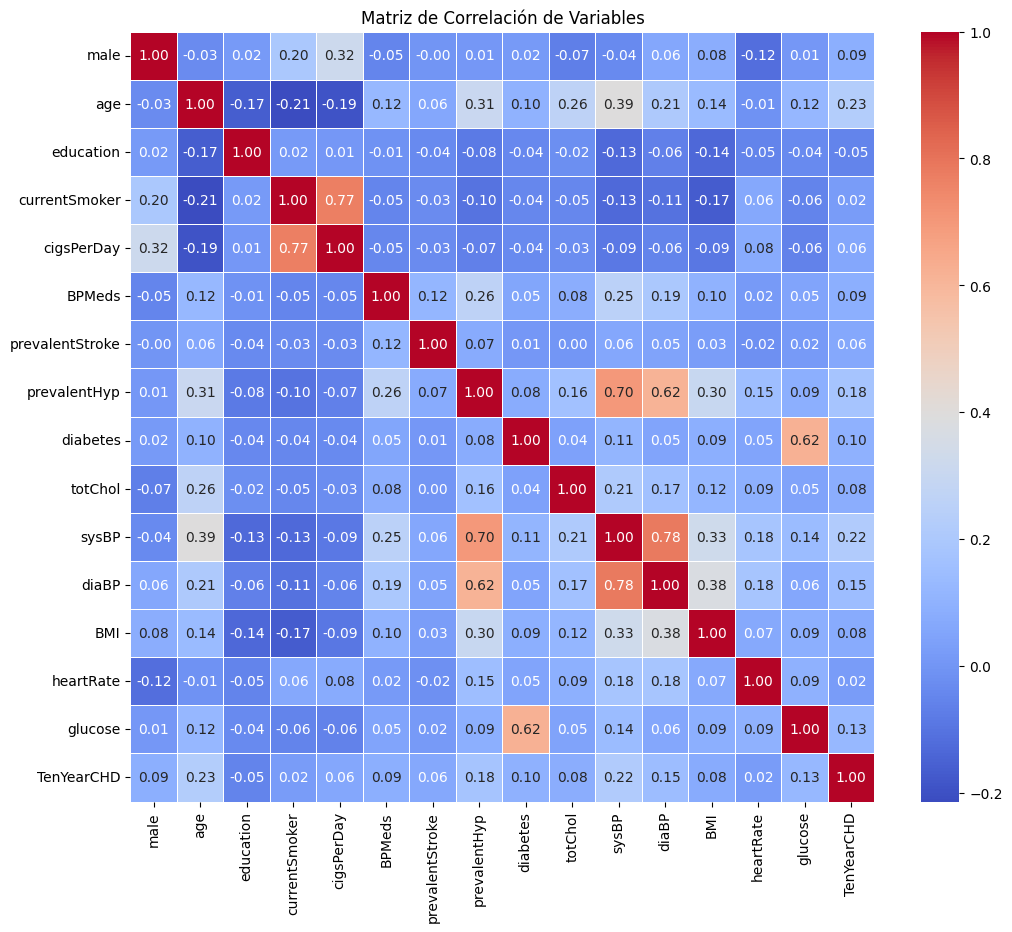

In [ ]:
correlation_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables')
plt.show()

Multicolinealidad entre variables como:

- sysBP y diaBP = 0.78
- prevalentHyp y sysBP = 0.70
- glucose y diabetes = 0.62
- currentSmoker y cigsPerDay = 0.77

Variables más relacionadas con TenYearCHD:

- age	= 0.23
- sysBP	= 0.22
- diaBP	= 0.15
- prevalentHyp	= 0.18

Tambien es importante:
- La variable education tiene una relacion negativa con mi variable dependiente
- La variable heartRate tiene una baja correlacion con mi variable dependiente
- prevalentStroke se mantendria si el enfoque fuera clinico pero como es plenamente estadistico no es importante
- Asi tenga faltantes la variable cigsperday es mas impornate que currentsmoker por que tiene mas relacion con mi variable dependiente


**Las variables que voy a usar para mi modelo son:**

- Variable dependiente: TenYearCHD
- Variables independientes: age, male, currentSmoker, sysBP, diabetes, BMI, totChol

pd:
-  La variable glucose tiene mas correlacion con la variable dependiente que diabetes pero en este caso usaremos la variable diabetes
- Asi tenga faltantes la variable cigsperday es mas impornate que currentsmoker por que tiene mas relacion con mi variable dependiente. En este caso usaremos currentsmoker

5. Eliminacion de faltantes

In [ ]:
df = df.dropna(subset=["totChol", "BMI"])

In [ ]:
df[["totChol", "BMI"]].isnull().sum()

,0
totChol,0
BMI,0


6. Hacemos el primer modelo de regresion logistica

In [ ]:
X = df[['age', 'male', 'currentSmoker', 'sysBP', 'diabetes', 'BMI', 'totChol']]
y = df['TenYearCHD']

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Datos escalados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo de regresion logistica
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train_scaled, y_train)

# Prediccion en el set de prueba
y_pred = model.predict(X_test_scaled)

# Evaluacion del modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.8396846254927727

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       638
           1       0.55      0.05      0.09       123

    accuracy                           0.84       761
   macro avg       0.69      0.52      0.50       761
weighted avg       0.80      0.84      0.78       761


Confusion Matrix:
[[633   5]
 [117   6]]


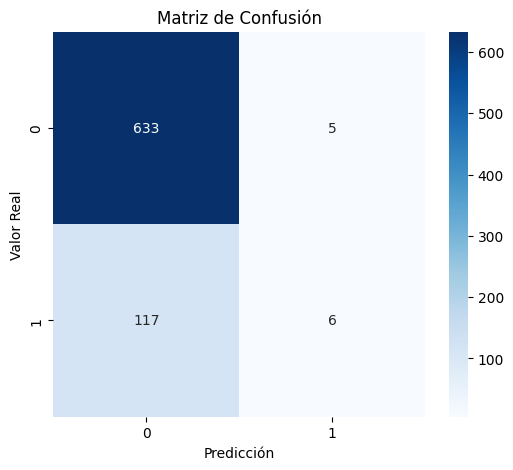

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión")
plt.show()

**ANALISIS MODELO #1**

El modelo 1 tiene un accuracy de 84%, lo que al principio parece un buen resultado. Sin embargo, al analizar la matriz de confusión se observa que el modelo clasifica muy bien a las personas que no tienen enfermedad (633 aciertos), pero falla en detectar a quienes sí la tienen, ya que solo identifica correctamente 6 de 123 casos reales. Esto se refleja en un recall muy bajo para la clase de enfermedad (0.05), lo que significa que el modelo casi no detecta los casos positivos. En general, aunque el porcentaje de aciertos es alto, el modelo no es muy bueno para un contexto médico porque deja pasar muchos casos de personas que sí podrían desarrollar la enfermedad.

7. Hacemos el modelo #2 de regresion logistica (Cambiamos "diabetes" por glucose y "currentsmoker" por cigsperday

In [ ]:
df = df.dropna(subset=["cigsPerDay", "glucose"])
df[["cigsPerDay", "glucose"]].isnull().sum()

,0
cigsPerDay,0
glucose,0


In [ ]:
X2 = df[['age', 'male', 'cigsPerDay', 'sysBP', 'glucose', 'BMI', 'totChol']]
y2 = df['TenYearCHD']

# Dividir los datos en entrenamiento y prueba
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Datos escalados
scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

# Modelo de regresion logistica
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X2_train_scaled, y2_train)

# Prediccion en el set de prueba
y2_pred = model.predict(X2_test_scaled)

# Evaluacion del modelo
accuracy = accuracy_score(y2_test, y2_pred)
report = classification_report(y2_test, y2_pred)
conf_matrix2 = confusion_matrix(y2_test, y2_pred)

print(f"Accuracy: {accuracy}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.8436268068331143

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       638
           1       0.67      0.07      0.12       123

    accuracy                           0.84       761
   macro avg       0.76      0.53      0.52       761
weighted avg       0.82      0.84      0.79       761


Confusion Matrix:
[[634   4]
 [115   8]]


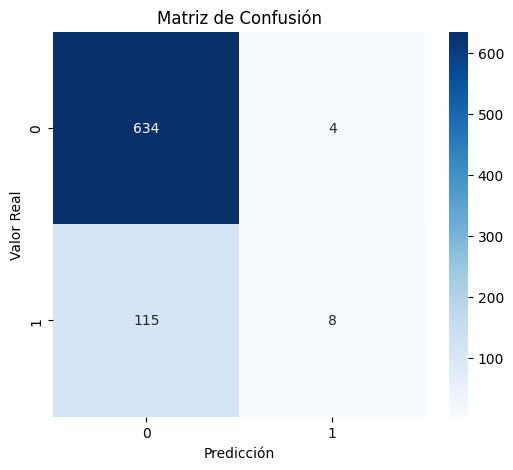

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix2,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión")
plt.show()

**ANALISIS MODELO #2**

El Modelo 2 presenta un accuracy de 84%, lo que en apariencia es un buen resultado, pero al analizar sus métricas se observa un desempeño muy desigual: clasifica casi perfectamente a las personas sanas (recall de 0.99 y 634 aciertos), mientras que falla gravemente en detectar a los enfermos, con un recall de apenas 0.07 y solo 8 aciertos. Esto significa que, aunque el modelo es confiable para identificar la ausencia de enfermedad, deja escapar la gran mayoría de los casos que sí la tienen, lo cual es crítico en un contexto médico. En conclusión, al igual que el modelo 1, el Modelo 2 no es adecuado para aplicaciones clínicas, ya que su baja sensibilidad compromete la detección temprana y el cuidado de los pacientes.


8. Modelo #3 solo usaremos las variables con mas coorrelacion con la variable dependiente

In [ ]:
X3 = df[['age', 'sysBP', 'glucose']]
y3 = df['TenYearCHD']

# Dividir los datos en entrenamiento y prueba
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

# Datos escalados
scaler = StandardScaler()
X3_train_scaled = scaler.fit_transform(X3_train)
X3_test_scaled = scaler.transform(X3_test)

# Modelo de regresion logistica
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X3_train_scaled, y3_train)

# Prediccion en el set de prueba
y3_pred = model.predict(X3_test_scaled)

# Evaluacion del modelo
accuracy = accuracy_score(y3_test, y3_pred)
report = classification_report(y3_test, y3_pred)
conf_matrix3 = confusion_matrix(y3_test, y3_pred)

print(f"Accuracy: {accuracy}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.835742444152431

Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       638
           1       0.25      0.01      0.02       123

    accuracy                           0.84       761
   macro avg       0.54      0.50      0.46       761
weighted avg       0.74      0.84      0.77       761


Confusion Matrix:
[[633   5]
 [117   6]]
